In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
PROJECT_PATH = "/content/drive/MyDrive/pluseguard"

PREPROCESSED_PATH = os.path.join(
    PROJECT_PATH,
    "Preprocessed"
)

HARDWARE_PATH = os.path.join(
    PROJECT_PATH,
    "hardware"
)

print("Preprocessed path exists:",
      os.path.exists(PREPROCESSED_PATH))

print("Hardware path exists:",
      os.path.exists(HARDWARE_PATH))

Preprocessed path exists: True
Hardware path exists: True


In [ ]:
X_train = np.load(
    os.path.join(PREPROCESSED_PATH, "X_train.npy")
)

y_train = np.load(
    os.path.join(PREPROCESSED_PATH, "y_train.npy")
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (9244, 1000)
y_train shape: (9244,)


In [ ]:
print("Normal training samples:",
      np.sum(y_train == 0))

print("MI training samples:",
      np.sum(y_train == 1))

Normal training samples: 5744
MI training samples: 3500


In [ ]:
hardware_file = os.path.join(
    HARDWARE_PATH,
    "ECG.csv"
)

hardware_df = pd.read_csv(hardware_file)

print("Hardware data shape:",
      hardware_df.shape)

print(hardware_df.head())

Hardware data shape: (5850, 2)
    Time  ECG
0  1.462  225
1  1.473  224
2  1.483  225
3  1.493  226
4  1.503  226


In [ ]:
print(hardware_df.columns.tolist())

['Time', 'ECG']


In [ ]:
time = hardware_df["Time"].values
ecg_hardware = hardware_df["ECG"].values

In [ ]:
print("Number of hardware samples:",
      len(ecg_hardware))

print("Minimum:",
      np.min(ecg_hardware))

print("Maximum:",
      np.max(ecg_hardware))

print("Mean:",
      np.mean(ecg_hardware))

print("Standard deviation:",
      np.std(ecg_hardware))

Number of hardware samples: 5850
Minimum: 218
Maximum: 233
Mean: 227.12341880341882
Standard deviation: 1.9442174451887695


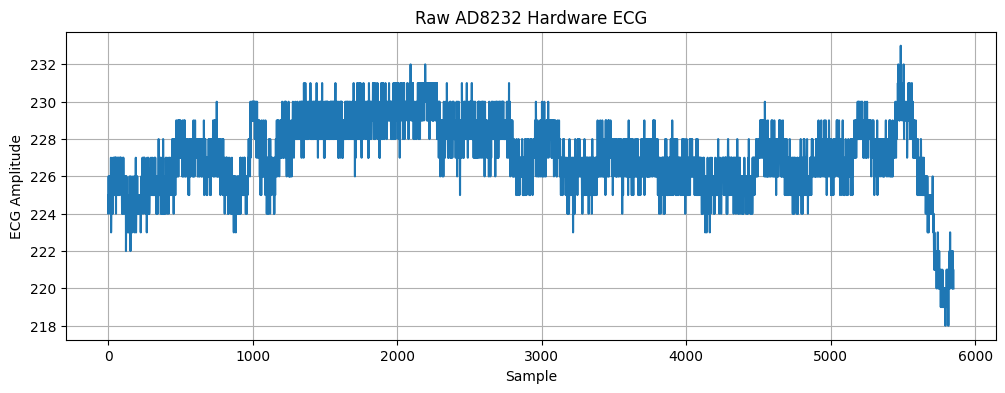

In [ ]:
plt.figure(figsize=(12, 4))

plt.plot(ecg_hardware)

plt.title("Raw AD8232 Hardware ECG")
plt.xlabel("Sample")
plt.ylabel("ECG Amplitude")
plt.grid(True)

plt.show()

In [ ]:
hardware_centered = (
    ecg_hardware - np.mean(ecg_hardware)
)

print("Mean after DC removal:",
      np.mean(hardware_centered))

Mean after DC removal: -1.166018848426831e-14


In [ ]:
FS = 100

print("Sampling frequency:", FS, "Hz")

Sampling frequency: 100 Hz


In [ ]:
def butter_lowpass_filter(signal, cutoff, fs, order=4):

    nyquist = 0.5 * fs

    normal_cutoff = cutoff / nyquist

    b, a = butter(
        order,
        normal_cutoff,
        btype="low"
    )

    return filtfilt(b, a, signal)

In [ ]:
baseline = butter_lowpass_filter(
    hardware_centered,
    cutoff=0.5,
    fs=FS,
    order=4
)

In [ ]:
low_frequency_component = butter_lowpass_filter(
    hardware_centered,
    cutoff=40,
    fs=FS,
    order=4
)

In [ ]:
high_frequency_noise = (
    hardware_centered -
    low_frequency_component
)

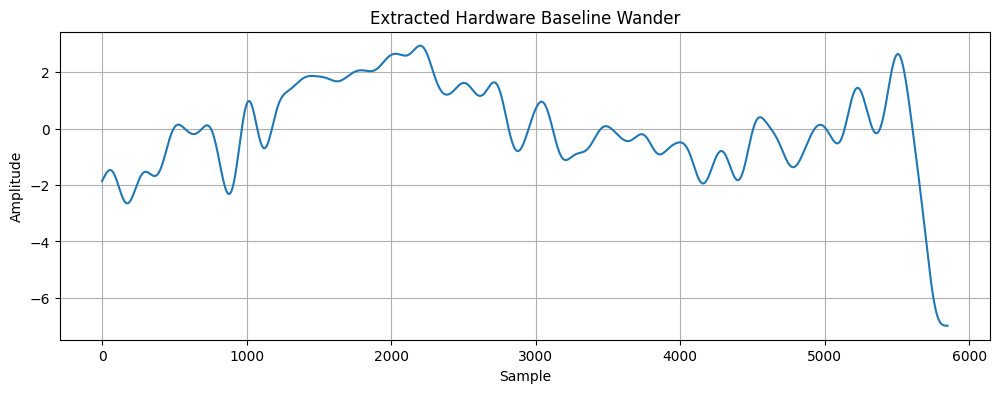

In [ ]:
plt.figure(figsize=(12, 4))

plt.plot(baseline)

plt.title("Extracted Hardware Baseline Wander")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.grid(True)

plt.show()

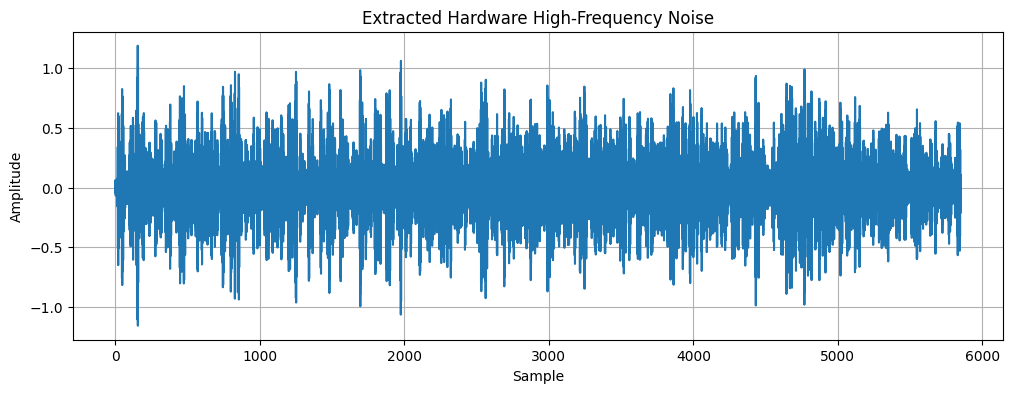

In [ ]:
plt.figure(figsize=(12, 4))

plt.plot(high_frequency_noise)

plt.title("Extracted Hardware High-Frequency Noise")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.grid(True)

plt.show()

In [ ]:
def standardize_signal(signal):

    mean = np.mean(signal)
    std = np.std(signal)

    if std == 0:
        return np.zeros_like(signal)

    return (signal - mean) / std

In [ ]:
hardware_noise = standardize_signal(
    high_frequency_noise
)

hardware_baseline = standardize_signal(
    baseline
)

In [ ]:
SEGMENT_LENGTH = 1000

print(
    "Segment duration:",
    SEGMENT_LENGTH / FS,
    "seconds"
)

Segment duration: 10.0 seconds


In [ ]:
def generate_real_hardware_noise(
    n_samples=1000
):

    max_start_noise = (
        len(hardware_noise) - n_samples
    )

    max_start_baseline = (
        len(hardware_baseline) - n_samples
    )

    noise_start = np.random.randint(
        0,
        max_start_noise + 1
    )

    baseline_start = np.random.randint(
        0,
        max_start_baseline + 1
    )

    noise_segment = hardware_noise[
        noise_start:
        noise_start + n_samples
    ]

    baseline_segment = hardware_baseline[
        baseline_start:
        baseline_start + n_samples
    ]

    # Random amplitudes
    noise_scale = np.random.uniform(
        0.05,
        0.20
    )

    baseline_scale = np.random.uniform(
        0.05,
        0.15
    )

    combined_noise = (
        noise_segment * noise_scale
        +
        baseline_segment * baseline_scale
    )

    return combined_noise

In [ ]:
def augment_ecg_with_hardware_noise(ecg):

    noise = generate_real_hardware_noise(
        len(ecg)
    )

    noisy_ecg = ecg + noise

    return noisy_ecg

In [ ]:
mi_indices = np.where(y_train == 1)[0]

print("Number of MI training samples:",
      len(mi_indices))

Number of MI training samples: 3500


In [ ]:
sample_index = mi_indices[0]

original_ecg = X_train[sample_index]

augmented_ecg = augment_ecg_with_hardware_noise(
    original_ecg
)

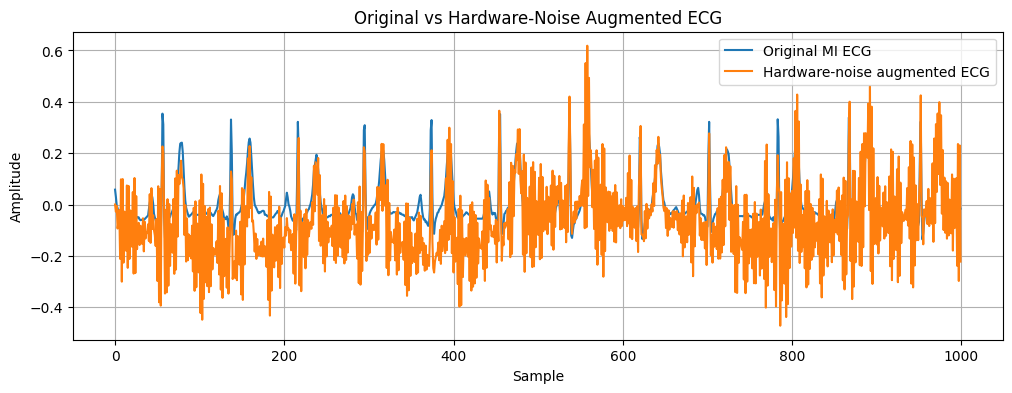

In [ ]:
plt.figure(figsize=(12, 4))

plt.plot(
    original_ecg,
    label="Original MI ECG"
)

plt.plot(
    augmented_ecg,
    label="Hardware-noise augmented ECG"
)

plt.title("Original vs Hardware-Noise Augmented ECG")

plt.xlabel("Sample")
plt.ylabel("Amplitude")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
X_mi = X_train[y_train == 1]

X_mi_augmented = np.array([
    augment_ecg_with_hardware_noise(ecg)
    for ecg in X_mi
])

y_mi_augmented = np.ones(
    len(X_mi_augmented),
    dtype=np.int32
)

print(
    "Augmented MI shape:",
    X_mi_augmented.shape
)

print(
    "Augmented MI labels:",
    y_mi_augmented.shape
)

Augmented MI shape: (3500, 1000)
Augmented MI labels: (3500,)


In [ ]:
X_train_augmented = np.concatenate(
    [
        X_train,
        X_mi_augmented
    ],
    axis=0
)

y_train_augmented = np.concatenate(
    [
        y_train,
        y_mi_augmented
    ],
    axis=0
)

In [ ]:
print(
    "Original training shape:",
    X_train.shape
)

print(
    "Augmented training shape:",
    X_train_augmented.shape
)

print(
    "Original labels:",
    y_train.shape
)

print(
    "Augmented labels:",
    y_train_augmented.shape
)

Original training shape: (9244, 1000)
Augmented training shape: (12744, 1000)
Original labels: (9244,)
Augmented labels: (12744,)


In [ ]:
print(
    "Normal (0):",
    np.sum(y_train_augmented == 0)
)

print(
    "MI (1):",
    np.sum(y_train_augmented == 1)
)

Normal (0): 5744
MI (1): 7000


In [ ]:
X_val = np.load(
    os.path.join(PREPROCESSED_PATH, "X_val.npy")
)

y_val = np.load(
    os.path.join(PREPROCESSED_PATH, "y_val.npy")
)

X_test = np.load(
    os.path.join(PREPROCESSED_PATH, "X_test.npy")
)

y_test = np.load(
    os.path.join(PREPROCESSED_PATH, "y_test.npy")
)

In [ ]:
print("Validation:", X_val.shape)
print("Testing:", X_test.shape)

Validation: (2312, 1000)
Testing: (2889, 1000)


In [ ]:
AUGMENTED_PATH = os.path.join(
    PROJECT_PATH,
    "Augmented"
)

os.makedirs(
    AUGMENTED_PATH,
    exist_ok=True
)

In [ ]:
np.save(
    os.path.join(
        AUGMENTED_PATH,
        "X_train_augmented.npy"
    ),
    X_train_augmented
)

np.save(
    os.path.join(
        AUGMENTED_PATH,
        "y_train_augmented.npy"
    ),
    y_train_augmented
)

print("Augmented training data saved successfully.")

Augmented training data saved successfully.
